In [1]:
import torch
import math
import torch.nn as nn

# This is an introductory example to learn about PyTorch.
# In PyTorch, the concept of a "network" is represented by nn.Module,
# and the forward() function defines the forward computation process.
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=4096):
        super().__init__()
        # Initialize the positional encoding matrix
        self.pe = torch.zeros(max_len, d_model)
        # Position indices [max_len, 1]
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        
        # For position encoding:
        # Even dimensions use sin(pos / 10000^(2i/d_model))
        # Odd dimensions use cos(pos / 10000^(2i/d_model))
        
        # Compute the scaling factor inside the sine/cosine function: 1 / 10000^(2i/d_model)
        # Equivalent expression:
        # exp(x * (-log(10000) / d_model)) = exp(-log(10000) * x / d_model)
        #                                = 1 / (10000^(x / d_model))
        
        # div_term = torch.exp(
        #     torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        # )  # Frequency factor [d_model/2]
        
        div_term = 10000.0 ** (torch.arange(0, d_model, 2).float() / d_model)
        
        # Apply sine to even dimensions and cosine to odd dimensions
        self.pe[:, 0::2] = torch.sin(position * div_term)  # even indices → sin
        self.pe[:, 1::2] = torch.cos(position * div_term)  # odd indices → cos

    def forward(self, x):
        # Slice the positional encodings to match input length, then add to input
        return x + self.pe[:x.size(1)]


In [2]:
pe = SinusoidalPositionalEncoding(40, 32)

In [3]:
pe.pe

tensor([[ 0.0000,  1.0000,  0.0000,  ...,  1.0000,  0.0000,  1.0000],
        [ 0.8415,  0.5403,  0.9999,  ..., -0.7820,  0.9505,  0.3109],
        [ 0.9093, -0.4161, -0.0282,  ...,  0.2231,  0.5909, -0.8067],
        ...,
        [-0.6636, -0.7481,  0.9176,  ..., -0.7861, -0.9670,  0.2548],
        [-0.9880,  0.1543, -0.4104,  ...,  0.2300, -0.0530,  0.9986],
        [-0.4040,  0.9147, -0.9060,  ...,  0.4262,  0.9289,  0.3704]])

In [4]:
x =  torch.zeros(32, 40)
x

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [5]:
r = pe(x)
r

tensor([[ 0.0000,  1.0000,  0.0000,  ...,  1.0000,  0.0000,  1.0000],
        [ 0.8415,  0.5403,  0.9999,  ..., -0.7820,  0.9505,  0.3109],
        [ 0.9093, -0.4161, -0.0282,  ...,  0.2231,  0.5909, -0.8067],
        ...,
        [-0.6636, -0.7481,  0.9176,  ..., -0.7861, -0.9670,  0.2548],
        [-0.9880,  0.1543, -0.4104,  ...,  0.2300, -0.0530,  0.9986],
        [-0.4040,  0.9147, -0.9060,  ...,  0.4262,  0.9289,  0.3704]])

In [6]:
r[1]

tensor([ 0.8415,  0.5403,  0.9999, -0.0141,  0.5889, -0.8082, -0.7443, -0.6679,
         0.0264,  0.9997, -0.5440, -0.8391, -0.1405, -0.9901, -0.0139,  0.9999,
         0.8573, -0.5148,  0.2608,  0.9654, -0.5064,  0.8623,  0.9871,  0.1604,
        -0.1383,  0.9904,  0.7677, -0.6409,  0.4819, -0.8762,  0.8269,  0.5624,
         0.9992,  0.0402, -0.9832,  0.1826, -0.6233, -0.7820,  0.9505,  0.3109])

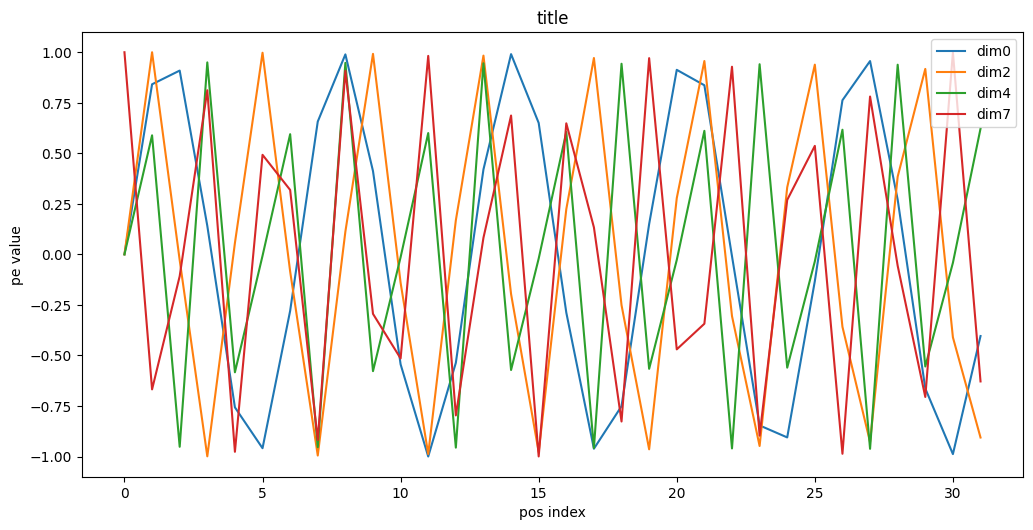

In [16]:
import torch
import math
import numpy as np
import matplotlib.pyplot as plt


seq_len= 32 
selected_dims =8
plt.figure(figsize=(20, 10))
plt.subplot(2, 2, 2)
dims_to_plot = np.linspace(0, selected_dims-1, 4, dtype=int)

for i in dims_to_plot:
    plt.plot(r[:, i], label=f"dim{i}")
    
plt.xlabel("pos index")
plt.ylabel("pe value")
plt.title("title")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
max_length = 40
d_model = 32
pos = torch.arange(0, max_length, dtype=torch.float).unsqueeze(1) # [40,1]
pos

tensor([[ 0.],
        [ 1.],
        [ 2.],
        [ 3.],
        [ 4.],
        [ 5.],
        [ 6.],
        [ 7.],
        [ 8.],
        [ 9.],
        [10.],
        [11.],
        [12.],
        [13.],
        [14.],
        [15.],
        [16.],
        [17.],
        [18.],
        [19.],
        [20.],
        [21.],
        [22.],
        [23.],
        [24.],
        [25.],
        [26.],
        [27.],
        [28.],
        [29.],
        [30.],
        [31.],
        [32.],
        [33.],
        [34.],
        [35.],
        [36.],
        [37.],
        [38.],
        [39.]])

In [18]:
div_term = 10000.0**(torch.arange(0, d_model, 2).float() / d_model)  #[16]

div_term

tensor([1.0000e+00, 1.7783e+00, 3.1623e+00, 5.6234e+00, 1.0000e+01, 1.7783e+01,
        3.1623e+01, 5.6234e+01, 1.0000e+02, 1.7783e+02, 3.1623e+02, 5.6234e+02,
        1.0000e+03, 1.7783e+03, 3.1623e+03, 5.6234e+03])

In [19]:
pos/div_term

tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [1.0000e+00, 5.6234e-01, 3.1623e-01, 1.7783e-01, 1.0000e-01, 5.6234e-02,
         3.1623e-02, 1.7783e-02, 1.0000e-02, 5.6234e-03, 3.1623e-03, 1.7783e-03,
         1.0000e-03, 5.6234e-04, 3.1623e-04, 1.7783e-04],
        [2.0000e+00, 1.1247e+00, 6.3246e-01, 3.5566e-01, 2.0000e-01, 1.1247e-01,
         6.3246e-02, 3.5566e-02, 2.0000e-02, 1.1247e-02, 6.3246e-03, 3.5566e-03,
         2.0000e-03, 1.1247e-03, 6.3246e-04, 3.5566e-04],
        [3.0000e+00, 1.6870e+00, 9.4868e-01, 5.3348e-01, 3.0000e-01, 1.6870e-01,
         9.4868e-02, 5.3348e-02, 3.0000e-02, 1.6870e-02, 9.4868e-03, 5.3348e-03,
         3.0000e-03, 1.6870e-03, 9.4868e-04, 5.3348e-04],
        [4.0000e+00, 2.2494e+00, 1.2649e+00, 7.1131e-01, 4.0000e-01, 2.2494e-01,
         1.2649e-01, 7.1131e-02, 4.0000